In [1]:
import mne

epochs = mne.read_epochs("/Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif", preload=True)
# Make sure these epochs are already trial‑aligned with your RW CSV
print(epochs)


Reading /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
715 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 715 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~95.4 MiB, data loaded,
 'loss': 261
 'reward': 454>


In [2]:
from mne.time_frequency import tfr_morlet
import numpy as np

# epochs: cleaned, response-locked Epochs (one per trial)
epochs_pick = epochs.copy()

freqs = np.linspace(8, 12, 5)       # alpha band
n_cycles = freqs / 2.0

power = tfr_morlet(
    epochs_pick, freqs=freqs, n_cycles=n_cycles,
    use_fft=True, return_itc=False, average=False
)
# power.data: (n_trials, n_channels, n_freqs, n_times)

# Collapse over alpha freqs → single power value per time, per channel, per trial
X = power.data.mean(axis=2)         # shape: (n_trials, n_channels, n_times)
times = power.times

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


In [3]:
import pandas as pd

behav = pd.read_csv("participant_P001_session_1_RW_trialoutcome_singlealpha.csv")
behav = behav[behav["trial_type"] == "trial"].reset_index(drop=True)

# Align to EEG trials (truncate to min length)
n = min(len(X), len(behav))
X = X[:n]
trial_outcome = behav["trial_outcome"].values[:n]   # 1=reward, 0=loss (as in your file)

# Example label: previous-trial outcome predicting current trial's brain pattern
y = trial_outcome[:-1]          # labels from trial t-1
X = X[1:]                       # brain data from trial t
times = times                   # same time axis

In [4]:
from mne.decoding import GeneralizingEstimator, cross_val_multiscore
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline: z-score sensors at each time, then linear SVM
clf = make_pipeline(
    StandardScaler(),            # operates on channels dimension
    SVC(kernel="linear", C=1)
)

gen = GeneralizingEstimator(
    clf,
    scoring="roc_auc",           # AUC is robust for 0/1 labels
    n_jobs=1                     # set >1 if you want parallelism
)

scores = cross_val_multiscore(
    gen, X, y, cv=10             # 10-fold CV, like the paper
)
# scores shape: (n_splits, n_times_train, n_times_test)
scores_mean = scores.mean(axis=0)


/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:15<00:00,   16.30it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [01:31<00:00,  718.58it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:18<00:00,   13.72it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [01:32<00:00,  716.27it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:17<00:00,   14.75it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [01:32<00:00,  717.79it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:16<00:00,   15.37it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [01:31<00:00,  718.13it/s]
100%|██████████| Fitting Generalizing

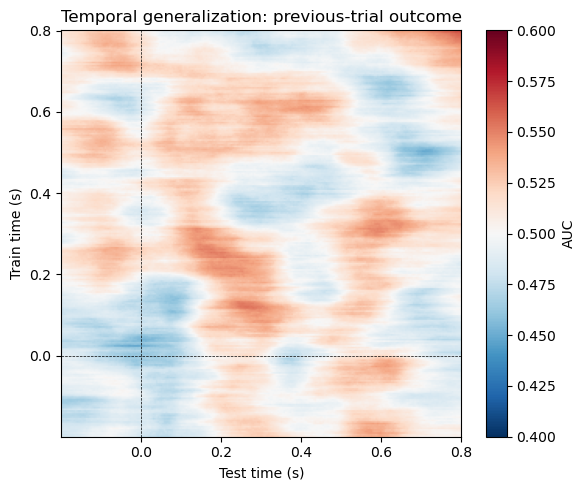

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
im = plt.imshow(
    scores_mean,
    origin="lower",
    extent=[times[0], times[-1], times[0], times[-1]],
    aspect="auto",
    vmin=0.4, vmax=0.6, cmap="RdBu_r"
)
plt.colorbar(im, label="AUC")
plt.xlabel("Test time (s)")
plt.ylabel("Train time (s)")
plt.title("Temporal generalization: previous-trial outcome")
plt.axhline(0, color="k", linestyle="--", linewidth=0.5)
plt.axvline(0, color="k", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import pandas as pd
from mne.time_frequency import tfr_morlet

# --- alpha power as before ---
epochs_pick = epochs.copy()                   # response-locked
freqs = np.linspace(8, 12, 5)
n_cycles = freqs / 2.0

power = tfr_morlet(
    epochs_pick, freqs=freqs, n_cycles=n_cycles,
    use_fft=True, return_itc=False, average=False
)
X = power.data.mean(axis=2)                  # (trials, channels, times)
times = power.times

# --- labels: previous-trial outcome ---
behav = pd.read_csv("participant_P001_session_1_RW_trialoutcome_singlealpha.csv")
behav = behav[behav["trial_type"] == "trial"].reset_index(drop=True)

n = min(len(X), len(behav))
X = X[:n]
outcome = behav["trial_outcome"].values[:n]  # 1=reward, 0=loss

y_prev = outcome[:-1]                        # label = outcome at t-1
X = X[1:]                                    # brain at t


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


In [8]:
def make_supertrials(X, y, k=10, random_state=0):
    rng = np.random.RandomState(random_state)
    X0 = X[y == 0]
    X1 = X[y == 1]
    k = min(k, len(X0), len(X1))
    rng.shuffle(X0)
    rng.shuffle(X1)
    X0_chunks = np.array_split(X0, k)
    X1_chunks = np.array_split(X1, k)
    X_super = np.array([c.mean(axis=0) for c in X0_chunks + X1_chunks])
    y_super = np.array([0]*k + [1]*k)
    return X_super, y_super

X_super, y_super = make_supertrials(X, y_prev, k=10)


In [9]:
from mne.decoding import GeneralizingEstimator
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1)
)
gen = GeneralizingEstimator(clf, scoring="roc_auc", n_jobs=1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = []

for train, test in cv.split(X_super, y_super):
    scores_fold = gen.fit(X_super[train], y_super[train]).score(X_super[test], y_super[test])
    scores.append(scores_fold)

scores = np.stack(scores, axis=0)            # (n_folds, n_train, n_test)
scores_mean = scores.mean(axis=0)            # temporal gen matrix


100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1657.85it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:49<00:00, 1334.99it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1778.29it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:51<00:00, 1277.45it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1208.61it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:52<00:00, 1266.49it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1707.72it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:55<00:00, 1199.75it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1529.23it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:53<00:00, 1244.66it/s]


In [12]:
n_perm = 100
perm_scores = np.zeros((n_perm, scores_mean.shape[0], scores_mean.shape[1]))

for p in range(n_perm):
    y_perm = np.random.permutation(y_super)
    ps = []
    for train, test in cv.split(X_super, y_perm):
        ps_fold = gen.fit(X_super[train], y_perm[train]).score(X_super[test], y_perm[test])
        ps.append(ps_fold)
    perm_scores[p] = npstack(ps, axis=0).mean(axis=0)

# threshold = 95th percentile of permuted distribution at each pixel
thr = np.percentile(perm_scores, 95, axis=0)
sig_mask = scores_mean > thr                 # boolean matrix where decoding is above chance


100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1548.88it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:49<00:00, 1322.01it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1433.93it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:50<00:00, 1311.74it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1661.81it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:51<00:00, 1282.02it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1647.11it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:49<00:00, 1326.77it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1596.62it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/66049 [00:49<00:00, 1325.71it/s]
100%|██████████| Fitting GeneralizingEstimator : 257/257 [00:00<00:00, 1641.62it/s]
100%|██████████| Scoring GeneralizingEstimator : 66049/6

KeyboardInterrupt: 

NameError: name 'sig_mask' is not defined

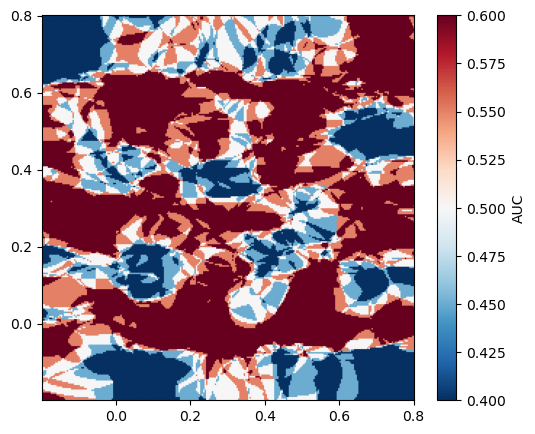

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
im = plt.imshow(
    scores_mean,
    origin="lower",
    extent=[times[0], times[-1], times[0], times[-1]],
    aspect="auto",
    vmin=0.4, vmax=0.6, cmap="RdBu_r"
)
plt.colorbar(im, label="AUC")
plt.contour(
    times, times, sig_mask,
    levels=[0.5], colors="k", linewidths=0.8
)
plt.xlabel("Test time (s)")
plt.ylabel("Train time (s)")
plt.title("Temporal generalization (super-trials, prev outcome)")
plt.axhline(0, color="k", linestyle="--", linewidth=0.5)
plt.axvline(0, color="k", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
